   # University of Gondar
  ## Collage of Informatics
## Department of Information Science
## Msc in Data Science and Analytics
### Course: Introduction to data science and Analytics 
### Project 2 : Customer Churn Prediction


#### Eyob Birhanu Haile
#### March, 2025

# **STEP 1: Pre processing**

## **1.1. LOADING THE NECESSARY LIBRARIES AND THE DATASET**

In [3]:
import pandas as pd
CustomerChurn_df = pd.read_csv('CustomerChurn.csv')

### **Explore the dataset**

In [4]:
CustomerChurn_df

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,810338,6840-RESVB,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,230811,2234-XADUH,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,155157,4801-JZAZL,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,731782,8361-LTMKD,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
CustomerChurn_df.describe()

,LoyaltyID,Tenure,Monthly Charges
count,7043.000000,7043.000000,7043.000000
mean,550382.651001,32.371149,64.761692
std,260776.118690,24.559481,30.090047
min,100346.000000,0.000000,18.250000
25%,323604.500000,9.000000,35.500000
50%,548704.000000,29.000000,70.350000
75%,776869.000000,55.000000,89.850000
max,999912.000000,72.000000,118.750000


## **1.2. CHECKING FOR MISSING VALUES**

In [6]:
CustomerChurn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [7]:
CustomerChurn_df.isna().sum()

LoyaltyID            0
Customer ID          0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

### **We can see that their is no missing values.**

## **1.3. LABEL ENCODING**

### **Check for the type of data that each feature contains**

In [8]:
CustomerChurn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [9]:
numeric_features = CustomerChurn_df.select_dtypes(include=['number']).columns.tolist()
non_numeric_features = CustomerChurn_df.select_dtypes(exclude=['number']).columns.tolist()
text_data_features = CustomerChurn_df.select_dtypes(include=['object']).columns.tolist()
print("Numeric features:", numeric_features, "\n\nNon_numeric_features:", non_numeric_features, "\n\nText data features:", text_data_features)

Numeric features: ['LoyaltyID', 'Tenure', 'Monthly Charges'] 

Non_numeric_features: ['Customer ID', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn'] 

Text data features: ['Customer ID', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn']


### As we can observe, 'Customer ID', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges' and 'Churn'  
### So, we need to transform them.

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() # Initialize the LabelEncoder

# Fit and transform the features
CustomerChurn_df['Customer ID'] = label_encoder.fit_transform(CustomerChurn_df['Customer ID'])
CustomerChurn_df['Senior Citizen'] = label_encoder.fit_transform(CustomerChurn_df['Senior Citizen'])
CustomerChurn_df['Partner'] = label_encoder.fit_transform(CustomerChurn_df['Partner'])
CustomerChurn_df['Dependents'] = label_encoder.fit_transform(CustomerChurn_df['Dependents'])
CustomerChurn_df['Phone Service'] = label_encoder.fit_transform(CustomerChurn_df['Phone Service'])

CustomerChurn_df['Multiple Lines'] = label_encoder.fit_transform(CustomerChurn_df['Multiple Lines'])
CustomerChurn_df['Internet Service'] = label_encoder.fit_transform(CustomerChurn_df['Internet Service'])
CustomerChurn_df['Online Security'] = label_encoder.fit_transform(CustomerChurn_df['Online Security'])
CustomerChurn_df['Online Backup'] = label_encoder.fit_transform(CustomerChurn_df['Online Backup'])

CustomerChurn_df['Device Protection'] = label_encoder.fit_transform(CustomerChurn_df['Device Protection'])
CustomerChurn_df['Tech Support'] = label_encoder.fit_transform(CustomerChurn_df['Tech Support'])
CustomerChurn_df['Streaming TV'] = label_encoder.fit_transform(CustomerChurn_df['Streaming TV'])
CustomerChurn_df['Streaming Movies'] = label_encoder.fit_transform(CustomerChurn_df['Streaming Movies'])

CustomerChurn_df['Contract'] = label_encoder.fit_transform(CustomerChurn_df['Contract'])
CustomerChurn_df['Paperless Billing'] = label_encoder.fit_transform(CustomerChurn_df['Paperless Billing'])
CustomerChurn_df['Payment Method'] = label_encoder.fit_transform(CustomerChurn_df['Payment Method'])
CustomerChurn_df['Total Charges'] = label_encoder.fit_transform(CustomerChurn_df['Total Charges'])
CustomerChurn_df['Churn'] = label_encoder.fit_transform(CustomerChurn_df['Churn'])

### Now we have encoded (transformed) all the non-numeric features

### Our churn_df contains numerical values for all of its features

### Check the transformed feature values

In [11]:
numeric_features = CustomerChurn_df.select_dtypes(include=['number']).columns.tolist()
non_numeric_features = CustomerChurn_df.select_dtypes(exclude=['number']).columns.tolist()
text_data_features = CustomerChurn_df.select_dtypes(include=['object']).columns.tolist()
print("Numeric features:", numeric_features, "\n\nNon_numeric_features:", non_numeric_features, "\n\nText data features:", text_data_features)

Numeric features: ['LoyaltyID', 'Customer ID', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn'] 

Non_numeric_features: [] 

Text data features: []


### Now every categorical changed to numeric, which is suitable for ML algorithms

In [12]:
CustomerChurn_df

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,5375,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,152148,3962,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,326527,2564,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,845894,5535,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,503388,6511,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,810338,4853,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,230811,1525,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,155157,3367,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,731782,5934,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [13]:
CustomerChurn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   int64  
 7   Multiple Lines     7043 non-null   int64  
 8   Internet Service   7043 non-null   int64  
 9   Online Security    7043 non-null   int64  
 10  Online Backup      7043 non-null   int64  
 11  Device Protection  7043 non-null   int64  
 12  Tech Support       7043 non-null   int64  
 13  Streaming TV       7043 non-null   int64  
 14  Streaming Movies   7043 non-null   int64  
 15  Contract           7043 non-null   int64  
 16  Paperless Billing  7043 

## **1.4. Drop Unimportant features**

In [14]:
CustomerChurn_df = CustomerChurn_df.drop(columns=['LoyaltyID', 'Customer ID'])

In [15]:
CustomerChurn_df

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597,0
7039,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698,0
7040,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994,0
7041,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660,1


## **1.5. Split the features and target variable**

In [16]:
X = CustomerChurn_df.drop(columns=['Churn'])
y = CustomerChurn_df['Churn']

## **1.6. Variables correlaton analysis**

### Correlation between a feature and the target variable

In [17]:
# Compute the correlation matrix
featureCorrWithTarget = X.corrwith(y)

# Display the correlation matrix
print("Correlation between features and target:")
print(featureCorrWithTarget)

Correlation between features and target:
Senior Citizen       0.150889
Partner             -0.150448
Dependents          -0.164221
Tenure              -0.352229
Phone Service        0.011942
Multiple Lines       0.038037
Internet Service    -0.047291
Online Security     -0.289309
Online Backup       -0.195525
Device Protection   -0.178134
Tech Support        -0.282492
Streaming TV        -0.036581
Streaming Movies    -0.038492
Contract            -0.396713
Paperless Billing    0.191825
Payment Method       0.107062
Monthly Charges      0.193356
Total Charges        0.014479
dtype: float64


### Correlation between variables

A correlation matrix is a table showing correlation coefficients between variables. 

Each cell in the matrix represents the correlation between two variables. 

The value ranges from -1 to 1, where 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no correlation.

In [18]:
CustomerChurn_df.corr()

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
Senior Citizen,1.000000,0.016479,-0.211185,0.016567,0.008576,0.146185,-0.032310,-0.128221,-0.013632,-0.021398,-0.151268,0.030776,0.047266,-0.142554,0.156530,-0.038551,0.220173,0.037653,0.150889
Partner,0.016479,1.000000,0.452676,0.379697,0.017706,0.142410,0.000891,0.150828,0.153130,0.166330,0.126733,0.137341,0.129574,0.294806,-0.014877,-0.154798,0.096848,0.059568,-0.150448
Dependents,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024991,0.044590,0.152166,0.091015,0.080537,0.133524,0.046885,0.021321,0.243187,-0.111377,-0.040292,-0.113890,-0.009572,-0.164221
Tenure,0.016567,0.379697,0.159712,1.000000,0.008448,0.343032,-0.030359,0.325468,0.370876,0.371105,0.322942,0.289373,0.296866,0.671607,0.006152,-0.370436,0.247900,0.158523,-0.352229
Phone Service,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.020538,0.387436,-0.015198,0.024105,0.003727,-0.019158,0.055353,0.043870,0.002247,0.016505,-0.004184,0.247398,0.083195,0.011942
Multiple Lines,0.146185,0.142410,-0.024991,0.343032,-0.020538,1.000000,-0.109216,0.007141,0.117327,0.122318,0.011466,0.175059,0.180957,0.110842,0.165146,-0.176793,0.433576,0.114955,0.038037
Internet Service,-0.032310,0.000891,0.044590,-0.030359,0.387436,-0.109216,1.000000,-0.028416,0.036138,0.044944,-0.026047,0.107417,0.098350,0.099721,-0.138625,0.086140,-0.323260,-0.055724,-0.047291
Online Security,-0.128221,0.150828,0.152166,0.325468,-0.015198,0.007141,-0.028416,1.000000,0.185126,0.175985,0.285028,0.044669,0.055954,0.374416,-0.157641,-0.096726,-0.053878,0.042357,-0.289309
Online Backup,-0.013632,0.153130,0.091015,0.370876,0.024105,0.117327,0.036138,0.185126,1.000000,0.187757,0.195748,0.147186,0.136722,0.280980,-0.013370,-0.124847,0.119777,0.090756,-0.195525
Device Protection,-0.021398,0.166330,0.080537,0.371105,0.003727,0.122318,0.044944,0.175985,0.187757,1.000000,0.240593,0.276652,0.288799,0.350277,-0.038234,-0.135750,0.163652,0.105905,-0.178134


## Correlation Heatmap

A correlation heatmap is a graphical representation of a correlation matrix.

It uses color coding to represent the correlation coefficients, making it easier to visualize the strength and direction of correlations.

Typically, a heatmap uses a color gradient, where darker or more intense colors represent stronger correlations (positive or negative), while lighter colors indicate weaker correlations.

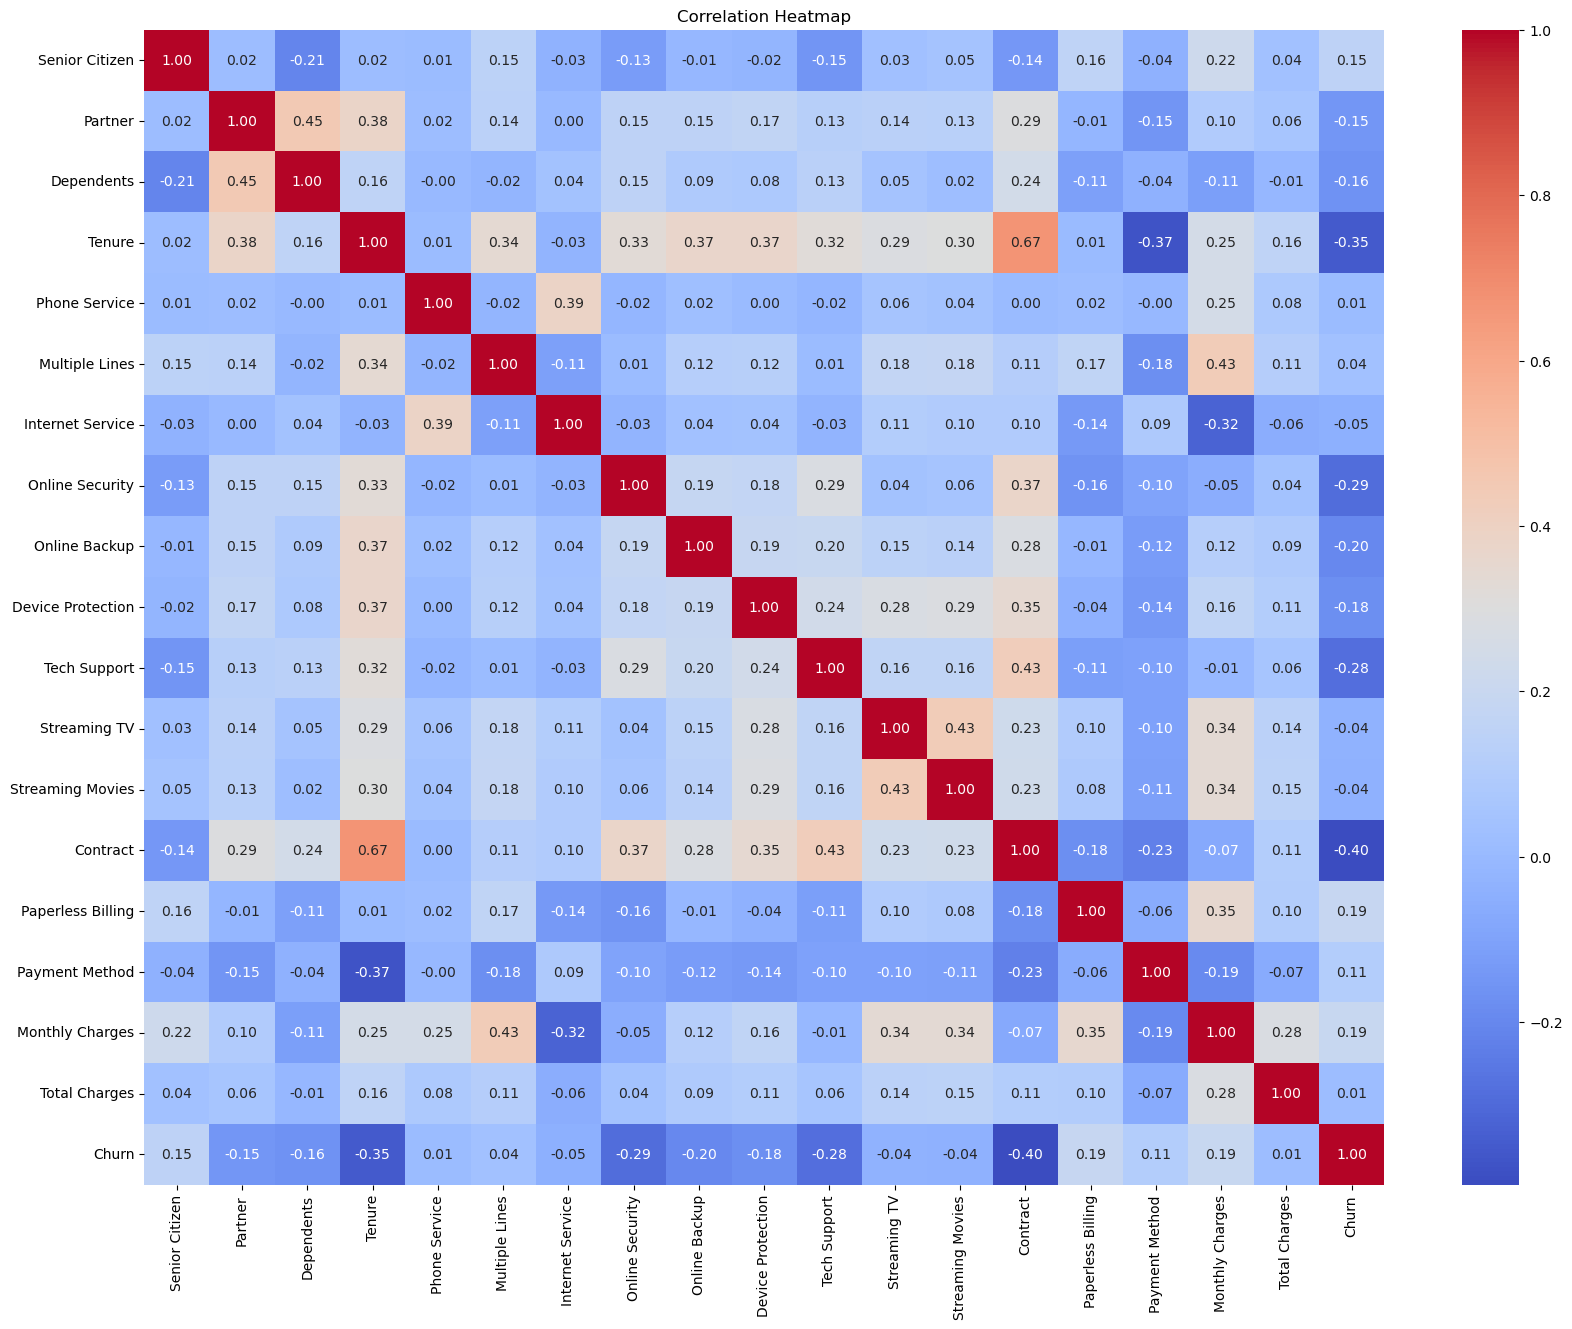

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = CustomerChurn_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## **1.7. Feature importance**

To determine the importance of a feature in predicting the charge of the insurance, we can use various methods. 

One common approach is to use tree-based models like Random Forests or Gradient Boosting, as they provide feature importance scores directly. 

Here's a step-by-step guide on how to do this using a Random Forest Regressor in Python:

1. Prepare the Data

    Ensure that your features (X) and target (y) are properly defined.

    Handle any missing values or categorical variables if necessary.

2. Train a Random Forest Regressor

    Train the model using your features and target.

    Extract feature importance scores from the trained model.

3. Visualize the Feature Importance

    Plot the feature importance scores for better interpretation.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as s

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance scores
feature_importance = rf.feature_importances_

# Create a DataFrame for visualization
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Add a Rank column
importance_df['Rank'] = importance_df.index + 1

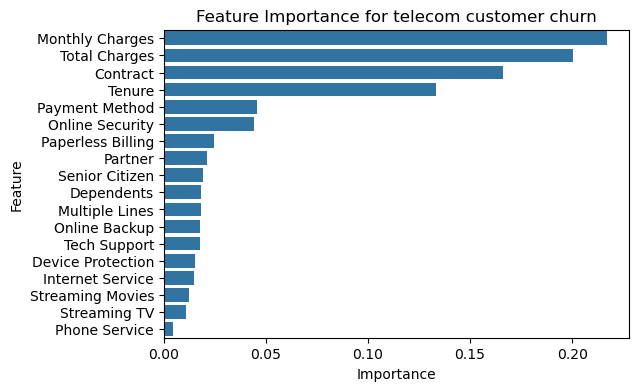

In [21]:
# Plot the feature importance
plt.figure(figsize=(6, 4))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for telecom customer churn')
plt.show()

In [22]:
# Display the DataFrame with ranks
importance_df = importance_df[['Rank', 'Feature', 'Importance']]
importance_df

,Rank,Feature,Importance
0,1,Monthly Charges,0.216893
1,2,Total Charges,0.200514
2,3,Contract,0.166080
3,4,Tenure,0.133084
4,5,Payment Method,0.045720
5,6,Online Security,0.043950
6,7,Paperless Billing,0.024389
7,8,Partner,0.021048
8,9,Senior Citizen,0.019379
9,10,Dependents,0.018231


## **1.8. Check for outliers**

Create a scatter plot for the features in churn_df (excluding the 'churn' column) against the target variable 'churn'. 

The following code will create a scatter plot for each feature in __churn_df__ against the target variable __'churn'__. 

Adjust the code according to your DataFrame's structure and the features you want to plot.

Here's how you can do it using Seaborn with different markers:

In [23]:
X.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges'],
      dtype='object')

As we discussed above, we can use methods like filtering based on statistical properties such as z-score or interquartile range (IQR), or using domain-specific knowledge and discard outliers from a DataFrame. 

Here, let's demonstrate how to remove outliers using the IQR method

In [24]:
CustomerChurn_df.shape

(7043, 19)

In [25]:
def remove_outliers_iqr(X, y):
    df = pd.concat([X, y], axis=1)
    
    # Apply IQR only to numeric features (ignore categorical ones like 'Churn')
    for feature in X.select_dtypes(include=['number']).columns:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

    X_clean = df[X.columns]
    y_clean = df[y.name]

    return X_clean, y_clean

# Assuming insurance_df is your dataframe, X and y are already defined
X_clean, y_clean = remove_outliers_iqr(X, y)
churn_df_no_outliers = pd.concat([X_clean, y_clean], axis=1)

# Print the shape of the DataFrame before and after outlier removal
print("Shape of X before outlier removal:", X.shape)
print("Shape of y before outlier removal:", y.shape)
print("Shape of X after outlier removal:", X_clean.shape)
print("Shape of y after outlier removal:", y_clean.shape)

Shape of X before outlier removal: (7043, 18)
Shape of y before outlier removal: (7043,)
Shape of X after outlier removal: (5323, 18)
Shape of y after outlier removal: (5323,)


### now outliers had been removed

In [26]:
churn_df_no_outliers

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
4,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1
5,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,6104,1
6,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1550,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,0,0,0,19,1,0,1,0,0,0,0,2,0,0,1,0,78.70,892,0
7037,0,0,0,72,1,0,2,1,1,1,1,1,1,2,1,0,21.15,770,0
7038,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597,0
7039,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698,0


In [46]:
X_clean

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
4,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
5,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,6104
6,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,0,0,0,19,1,0,1,0,0,0,0,2,0,0,1,0,78.70,892
7037,0,0,0,72,1,0,2,1,1,1,1,1,1,2,1,0,21.15,770
7038,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698


In [47]:
y_clean

1       0
2       1
4       1
5       1
6       0
       ..
7035    0
7037    0
7038    0
7039    0
7042    0
Name: Churn, Length: 5323, dtype: int64

In [49]:
churn_df_no_outliers["Churn"].value_counts()

Churn
0    4056
1    1267
Name: count, dtype: int64

### The scatter plot after the outliers are handled

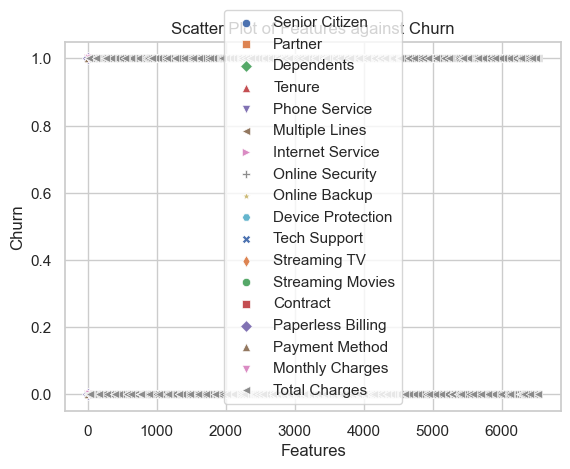

In [50]:
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'H', 'X', 'd']  # we can add more markers if we have more features

sns.set(style="whitegrid")

for i, feature in enumerate(X_clean.columns):
    sns.scatterplot(data=churn_df_no_outliers, x=feature, y='Churn', marker=markers[i % len(markers)], label=feature)

plt.xlabel('Features')
plt.ylabel('Churn')
plt.title('Scatter Plot of Features against Churn')
plt.legend()
plt.show()

## **1.9. Standardization and Normalization**

## Standardization

Transforms data to have a mean of zero and a standard deviation of one.

Formula:
$z=\frac{(x−μ)}{σ}​$
Where:

    x is the original feature value.
    μ is the mean of the feature.
    σ is the standard deviation of the feature.

This method is useful when the data is normally distributed or required to have a Gaussian distribution (e.g., linear regression, logistic regression).

It handles outliers better compared to normalization 

It is suitable for algorithms that assume data is normally distributed.
### To Standardize a data frame 

__from sklearn.preprocessing import StandardScaler__

__scaler = StandardScaler()__

__scaled_data = scaler.fit_transform(df)__

### To convert the scaled data back to a DataFrame
__scaled_df = pd.DataFrame(scaled_data, columns=df.columns)__

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_clean)

# Convert the scaled data back to a DataFrame
X_standardized_df = pd.DataFrame(X_standardized, columns=X_clean.columns)

# Combine scaled features and target back into a single DataFrame if needed
churn_df_standardized = pd.concat([X_standardized_df, y.reset_index(drop=True)], axis=1)

In [52]:
X_clean

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
4,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
5,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,6104
6,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,0,0,0,19,1,0,1,0,0,0,0,2,0,0,1,0,78.70,892
7037,0,0,0,72,1,0,2,1,1,1,1,1,1,2,1,0,21.15,770
7038,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698


In [53]:
X_standardized_df

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,0.0,-0.965829,-0.721403,0.071612,0.0,-0.874263,-1.292565,1.401389,-1.088095,1.283012,-1.011387,-1.164798,-1.160883,0.30384,-1.130788,1.283271,-0.227236,-0.947707
1,0.0,-0.965829,-0.721403,-1.225090,0.0,-0.874263,-1.292565,1.401389,1.274030,-1.080945,-1.011387,-1.164798,-1.160883,-0.87670,0.884339,1.283271,-0.327400,-1.633055
2,0.0,-0.965829,-0.721403,-1.225090,0.0,-0.874263,0.027275,-0.997966,-1.088095,-1.080945,-1.011387,-1.164798,-1.160883,-0.87670,0.884339,0.371031,0.217037,-1.230956
3,0.0,-0.965829,-0.721403,-0.981959,0.0,1.143821,0.027275,-0.997966,-1.088095,1.283012,-1.011387,1.187334,1.191374,-0.87670,0.884339,0.371031,1.152434,1.480592
4,0.0,-0.965829,1.386187,-0.414652,0.0,1.143821,0.027275,-0.997966,1.274030,-1.080945,-1.011387,1.187334,-1.160883,-0.87670,0.884339,-0.541209,0.811555,-0.903728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5318,0.0,-0.965829,-0.721403,-0.536217,0.0,-0.874263,0.027275,-0.997966,-1.088095,-1.080945,-1.011387,1.187334,-1.160883,-0.87670,0.884339,-1.453449,0.475523,-1.248234
5319,0.0,-0.965829,-0.721403,1.611446,0.0,-0.874263,1.347114,0.201712,0.092967,0.101033,0.184440,0.011268,0.015246,1.48438,0.884339,-1.453449,-1.383962,-1.312109
5320,0.0,1.035380,1.386187,-0.333608,0.0,1.143821,-1.292565,1.401389,-1.088095,1.283012,1.380267,1.187334,1.191374,0.30384,0.884339,1.283271,0.672619,-0.879120
5321,0.0,1.035380,1.386187,1.611446,0.0,1.143821,0.027275,-0.997966,1.274030,1.283012,-1.011387,1.187334,1.191374,0.30384,0.884339,-0.541209,1.267137,1.268024


## **1.10. Saving the pre processed dataset**

Save the normalized data frames (X_standardized_df and insurance_df_standardized) and a data series (y) to CSV

In [54]:
X_standardized_df.to_csv('it_churn_df_features.csv', index=False)

y_clean.to_csv('it_churn_df_target.csv', index=False)

churn_df_standardized.to_csv('it_df_standardized.csv', index=False)

# **STEP 2: TRAINING AND TESTING THE MODEL**

## **2.1. LOAD THE PRE-PROCESSED DATASET**

In [55]:
Xn = pd.read_csv('it_churn_df_features.csv')
yn = pd.read_csv('it_churn_df_target.csv')

In [56]:
# Optional: Check the first few rows of the data to confirm
print(Xn.head())
print(yn.head())

   Senior Citizen   Partner  Dependents    Tenure  Phone Service  \
0             0.0 -0.965829   -0.721403  0.071612            0.0   
1             0.0 -0.965829   -0.721403 -1.225090            0.0   
2             0.0 -0.965829   -0.721403 -1.225090            0.0   
3             0.0 -0.965829   -0.721403 -0.981959            0.0   
4             0.0 -0.965829    1.386187 -0.414652            0.0   

   Multiple Lines  Internet Service  Online Security  Online Backup  \
0       -0.874263         -1.292565         1.401389      -1.088095   
1       -0.874263         -1.292565         1.401389       1.274030   
2       -0.874263          0.027275        -0.997966      -1.088095   
3        1.143821          0.027275        -0.997966      -1.088095   
4        1.143821          0.027275        -0.997966       1.274030   

   Device Protection  Tech Support  Streaming TV  Streaming Movies  Contract  \
0           1.283012     -1.011387     -1.164798         -1.160883   0.30384   
1   

## **2.2. Split data into training and testing sets (80% training, 20% testing)**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(Xn, yn, test_size=0.2, random_state=42, shuffle=True)

# Optional: Check the shape of the splits
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4258, 18) (1065, 18) (4258, 1) (1065, 1)


## **2.3. TRAIN**

### **2.3.1. TRAIN USING Support Vector Machine**

In [58]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### **PREDICTING AND EVALUATING SVM MODEL**

In [59]:
from sklearn.metrics import confusion_matrix, classification_report
# Predict and evaluate
svm_predictions = svm_model.predict(X_test)

# Confusion Matrix to see how well the model distinguishes between classes
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_predictions))
print("Predictions: ", svm_predictions[:])
print("SVM Accuracy:", accuracy_score(y_test, svm_predictions))
print("SVM Classification Report:\n", classification_report(y_test, svm_predictions))

Confusion Matrix:
 [[784  43]
 [129 109]]
Predictions:  [1 0 0 ... 0 0 0]
SVM Accuracy: 0.8384976525821596
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90       827
           1       0.72      0.46      0.56       238

    accuracy                           0.84      1065
   macro avg       0.79      0.70      0.73      1065
weighted avg       0.83      0.84      0.82      1065



### **2.3.2. TRAIN USING DECISION TREE MODEL**

In [60]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### **PREDICTING AND EVALUATING DECISION TREE MODEL**

In [61]:
# Predict and evaluate
dt_predictions = dt_model.predict(X_test)


# Confusion Matrix to see how well the model distinguishes between classes
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_predictions))
print("Predictions: ", dt_predictions[:])
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_predictions))

Confusion Matrix:
 [[744  83]
 [125 113]]
Predictions:  [1 0 0 ... 0 0 0]
Decision Tree Accuracy: 0.8046948356807512
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88       827
           1       0.58      0.47      0.52       238

    accuracy                           0.80      1065
   macro avg       0.72      0.69      0.70      1065
weighted avg       0.79      0.80      0.80      1065



### **2.3.3. TRAIN USING RANDOM FOREST MODEL**

In [62]:
from sklearn.ensemble import RandomForestClassifier
# train the random forest model
rfmodel = RandomForestClassifier(random_state=42)
rfmodel.fit(X_train, y_train)

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### **PREDICTING AND EVALUATING RANDOM FOREST MODEL**

In [63]:
# Make predictions
rf_pred = rfmodel.predict(X_test)

# Confusion Matrix to see how well the model distinguishes between classes
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Predictions: ", rf_pred[:])
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))

Confusion Matrix:
 [[769  58]
 [122 116]]
Predictions:  [1 0 0 ... 0 0 0]
Random Forest Accuracy: 0.8309859154929577
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90       827
           1       0.67      0.49      0.56       238

    accuracy                           0.83      1065
   macro avg       0.76      0.71      0.73      1065
weighted avg       0.82      0.83      0.82      1065



### **2.3.4. TRAIN USING XG-BOOST MODEL**

In [64]:
from xgboost import XGBClassifier
# train the XG-BOOST model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### **PREDICTING AND EVALUATING XG-BOOST MODEL**

In [65]:
# Make predictions
xg_pred = xgb_model.predict(X_test)

# Confusion Matrix to see how well the model distinguishes between classes
print("Confusion Matrix:\n", confusion_matrix(y_test, xg_pred))
print("Predictions: ", xg_pred[:])
print("XG-BOOST Accuracy:", accuracy_score(y_test, xg_pred))
print("XG-BOOST Classification Report:\n", classification_report(y_test, xg_pred))

Confusion Matrix:
 [[768  59]
 [111 127]]
Predictions:  [1 0 0 ... 0 0 0]
XG-BOOST Accuracy: 0.8403755868544601
XG-BOOST Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       827
           1       0.68      0.53      0.60       238

    accuracy                           0.84      1065
   macro avg       0.78      0.73      0.75      1065
weighted avg       0.83      0.84      0.83      1065



## **2.3.5. ENSEMBLE MEDELLING**

In [68]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
# Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('xgb', XGBClassifier(n_estimators=100)),
    ('lgbm', LGBMClassifier(n_estimators=100))
]

# Define stacking model with Logistic Regression as final estimator
stacking_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

stacking_model.fit(X_train, y_train)

C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1029, number of negative: 3229
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 633
[LightGBM] [Info] Number of data points in the train set: 4258, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241663 -> initscore=-1.143585
[LightGBM] [Info] Start training from score -1.143585
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 823, number of negative: 2583
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 633
[LightGBM] [Info] Numbe

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


Accuracy: 0.8441
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       827
           1       0.73      0.48      0.58       238

    accuracy                           0.84      1065
   macro avg       0.80      0.71      0.74      1065
weighted avg       0.83      0.84      0.83      1065

Confusion Matrix:
[[785  42]
 [124 114]]


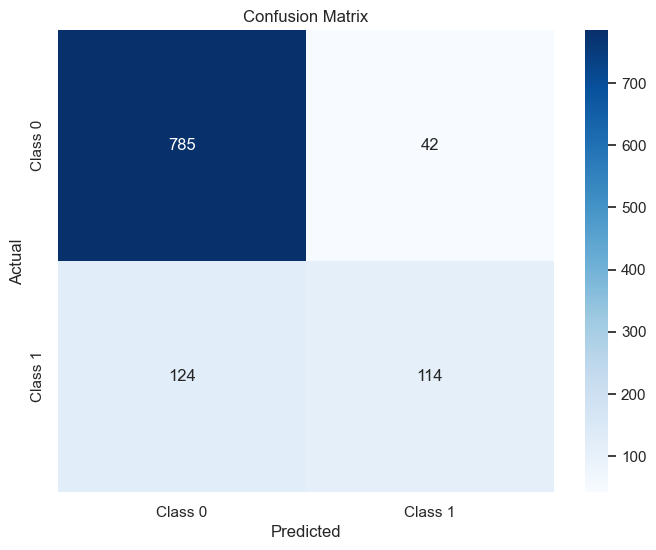

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already trained your model, e.g., stacking_model
# and X_test, y_test are your test data and labels

# Predicting the labels on test data
ensemble_pred = stacking_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, ensemble_pred)
print(f'Accuracy: {accuracy:.4f}')

# Classification report
report = classification_report(y_test, ensemble_pred)
print("Classification Report:")
print(report)

# Confusion Matrix
cm = confusion_matrix(y_test, ensemble_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()